### Работа с папками и файлами

#### Файлы и пути доступа к ним

Файл имеет два ключевых свойства: 
- имя файла (обычно записывается в виде одного слова) и
- путь доступа к файлу. 

Путь определяет, где именно располагается файл. 
Часть имени файла, которая следует за последней точкой, называется расширением имени файла и указывает на тип файла.


Папки могут содержать файлы и другие папки.

Часть, например, C:\ пути к файлу – это корневая папка, которая содержит все остальные папки. 

В Windows корневой является папка C:\, которая также называется диском C:. 

В OS X и Linux корневой является папка /.

Дополнительные тома будут отображаться по-разному в разных ОС. 

В Windows они отображаются в виде корневых дисков с другими буквенными обозначениями: D:\, E:\ и т.д. 

В OS X они отображаются в виде новых папок в папке /Volumes, 
в Linux – в виде новых папок в папке /mnt (от англ. mount). 

Кроме того, в Windows и OS X имена файлов и папок нечувствительны к регистру, в Linux они зависят от регистра.


### Модуль os

Ряд возможностей по работе с каталогами и файлами предоставляет встроенный модуль `os`. 

In [1]:
import os

Функция `os.name` позволяет получить информацию о том, с какой платформой вы работаете. 

Вам откроются следующие значения: ‘posix’, ‘nt’, ‘os2’, ‘ce’, ‘java’, ‘riscos’. 

In [2]:
os.name

'nt'

Значение `os.environ` известно как объект мэппинга (сопоставления), который работает со словарем переменных пользовательской среды. 

Это дает вам полезную информацию, такую как количество процессоров, тип ОЗУ, имя компьютера, и так далее. 

In [3]:
os.environ

environ{'ALLUSERSPROFILE': 'C:\\ProgramData',
        'APPDATA': 'C:\\Users\\Дмитрий\\AppData\\Roaming',
        'APPLICATIONINSIGHTS_CONFIGURATION_CONTENT': '{}',
        'APPLICATION_INSIGHTS_NO_DIAGNOSTIC_CHANNEL': '1',
        'CHROME_CRASHPAD_PIPE_NAME': '\\\\.\\pipe\\crashpad_13996_VDUBTHSFWSAUYIYM',
        'COMMONPROGRAMFILES': 'C:\\Program Files\\Common Files',
        'COMMONPROGRAMFILES(X86)': 'C:\\Program Files (x86)\\Common Files',
        'COMMONPROGRAMW6432': 'C:\\Program Files\\Common Files',
        'COMPUTERNAME': 'DESKTOP-MI0JPMD',
        'COMSPEC': 'C:\\WINDOWS\\system32\\cmd.exe',
        'DJANGO': 'C:\\Python38\\Scripts',
        'DRIVERDATA': 'C:\\Windows\\System32\\Drivers\\DriverData',
        'EFC_10108': '1',
        'ELECTRON_RUN_AS_NODE': '1',
        'HOMEDRIVE': 'C:',
        'HOMEPATH': '\\Users\\Дмитрий',
        'JPY_INTERRUPT_EVENT': '2264',
        'LOCALAPPDATA': 'C:\\Users\\Дмитрий\\AppData\\Local',
        'LOGONSERVER': '\\\\DESKTOP-MI0JPMD',
  

Это значит, что вы можете получить доступ к значениям среды, пользуясь обычными словарными методами. 

In [4]:
os.environ['TMP']

'C:\\Users\\AACE~1\\AppData\\Local\\Temp'

Если заданного значения среды не сущетсвует - получим исключение:

In [ ]:
os.environ['TMP2']

##### Использование обратной косой черты в Windows и косой черты в OS X и Linux

В Windows пути к файлам записывают, разделяя имена папок обратной косой чертой `(\)`. 
В OS X и Linux разделителем служит косая черта `(/)`. 

Для выполнения сценария в любой ОС – рассматривать оба случая.


##### Функция os.path.join(). 


Если ей передать строковые значения имен файлов и папок в своем пути доступа, то вызов `os.path.join()` возвратит строку, в которой путь доступа к файлу указан с использованием корректной версии разделителя. 


In [5]:
import os
os.path.join('python','mylabs','lab1')

'python\\mylabs\\lab1'

Функция `os.path.join()` оказывается полезной при создании строк для имен файлов. 


In [12]:
myfiles = ['account.txt', 'detail.txt','docs.doc']
for filename in myfiles:
    print(os.path.join('C:\\Users\\my', filename))

C:\Users\my\account.txt
C:\Users\my\detail.txt
C:\Users\my\docs.doc


#### Текущий рабочий каталог

Каждая программа, которая выполняется на компьютере, имеет `текущий рабочий каталог (current working directory — cwd)`. 

Предполагается, что любые имена файлов или пути, которые не начинаются с указания корневой папки, заданы относительно текущего рабочего каталога. 

Для получения значения текущего рабочего каталога в виде строки используется функция `os.getcwd()`, а для его изменения – функция `os.chdir()`. 


In [13]:
import os

print(os.getcwd())
os.chdir('C:\\')
print(os.getcwd())

C:\
C:\


При попытке перейти в несуществующий каталог Python выведет сообщение об ошибке.

In [14]:
os.chdir('H:\\')

FileNotFoundError: [WinError 3] Системе не удается найти указанный путь: 'H:\\'

#### Абсолютные и относительные пути доступа

Существуют два способа определения пути доступа к файлу:
- **абсолютный путь**, который всегда начинается с имени корневой папки;
- **относительный путь**, который задается относительно текущего рабочего каталога программы.


Существуют также папки, обозначаемые одним `(.)` или двумя `(..)` символами точки. 
Это не реальные папки, а специальные имена, которые могут использоваться при задании путей. 

Одиночная точка является сокращенным обозначением, имеющим смысл **"данная папка"**. 
Двойная точка имеет смысл **"родительская папка"**.

**Пример расположения папок и файлов**


В качестве текущего установлен рабочий каталог C:\my, то относительные пути к другим папкам и файлам задаются следующим образом

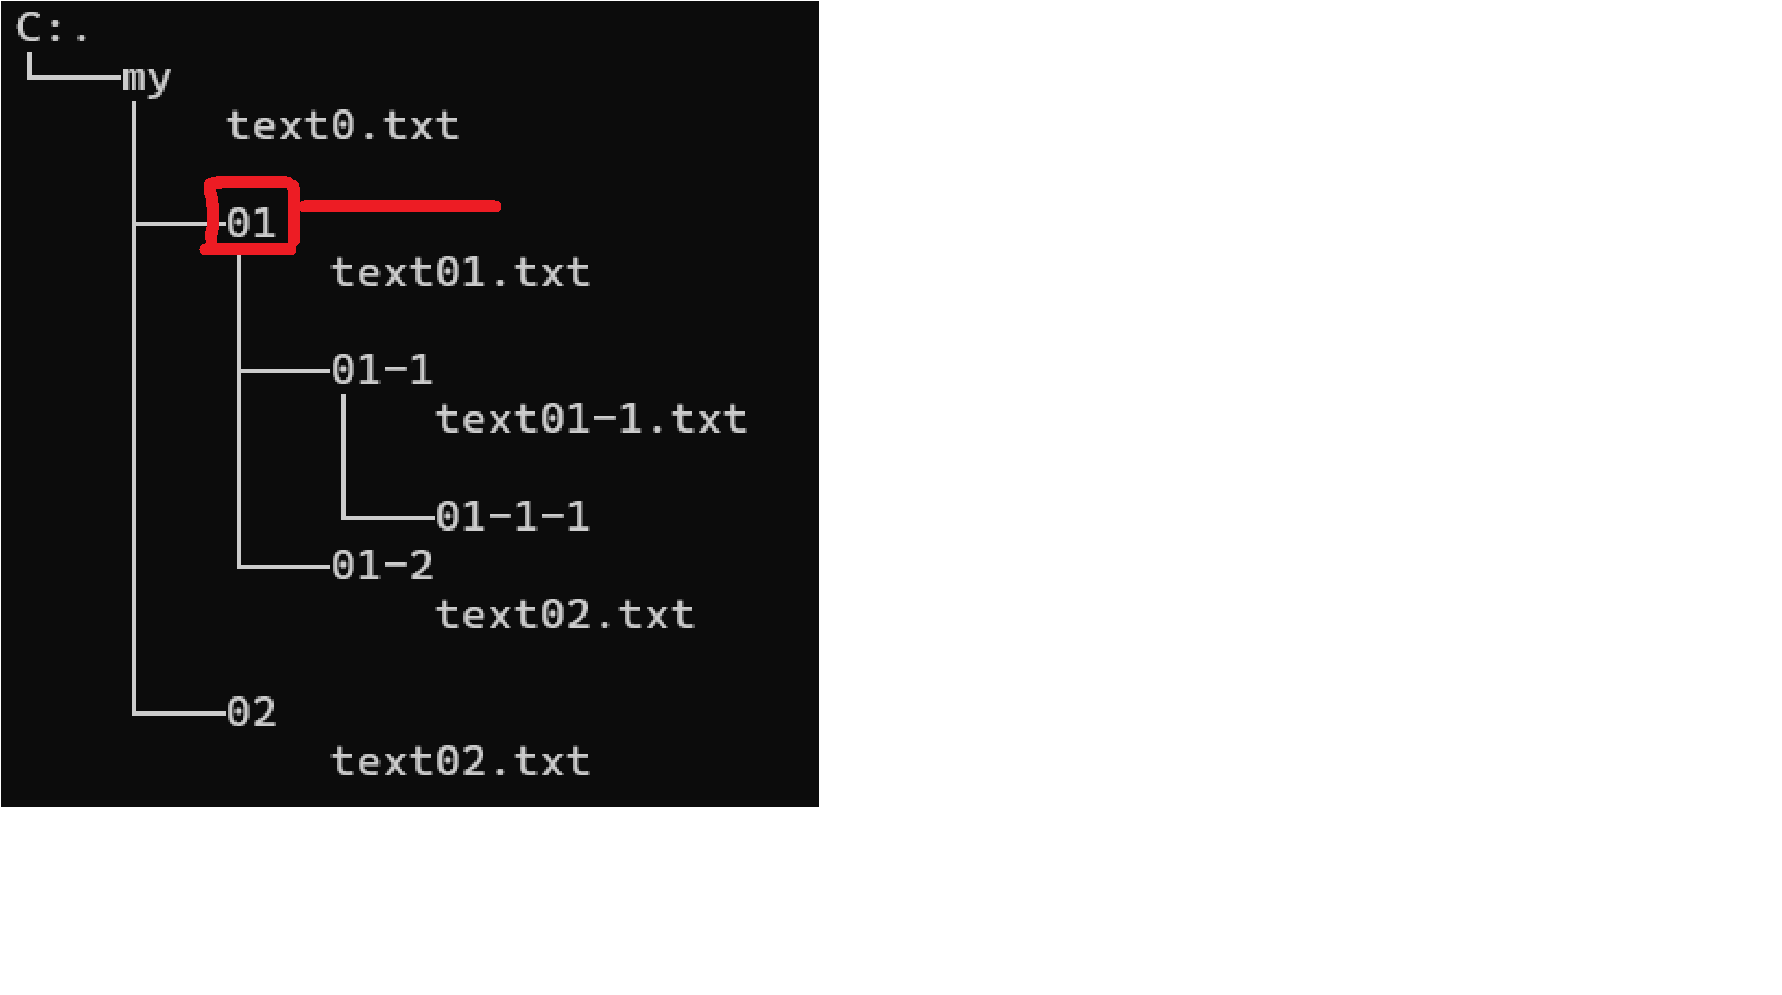

|Относительные пути|Абсолютные пути|
|-------|-------|
|`..\`  |`C:\`  |
|`.\`   |`C:\01`|
|`.\01-1`|`C:\01\01-1`|
|`.\text01.txt`|`C:\01\text01.txt`|
|`..\02`|`C:\my\02`|
|`..\02\text02.txt`|`C:\my\02\text02.txt`|
|`..\text0.txt`|`C:\my\text0.txt`|

##### Обработка абсолютных и относительных путей

Модуль `os.path` предоставляет функции для возврата абсолютного пути по заданному относительному пути и проверки того, является ли путь абсолютным.

Вызов `os.path.abspath(path)` возвращает строку абсолютного пути аргумента. Это простой способ преобразования относительного пути в абсолютный.

Вызов `os.path.isabs(path)` возвращает значение True, если аргумент – абсолютный путь, и False, если аргумент — относительный путь.


In [15]:
import os
os.getcwd()
os.chdir('C:\\my\\01')
print(os.path.abspath('.'))
print(os.path.abspath('..'))
print(os.path.abspath('.\\01-1'))
print(os.path.abspath('.\\text01.txt'))
print(os.path.abspath('..\\02'))
print(os.path.abspath('..\\02\\text02.txt'))
print(os.path.abspath('..\\text0.txt'))


FileNotFoundError: [WinError 3] Системе не удается найти указанный путь: 'C:\\my\\01'

In [16]:
print(os.path.isabs('.'))
print(os.path.isabs('C:\\my\\01'))
print(os.path.isabs(os.path.abspath('.')))


False
True
True


Вызов `os.path.relpath(path, start)` возвращает строку относительного пути от `start` к `path`. 

Если путь `start` не предоставлен, то в качестве него используется текущий рабочий каталог.


In [17]:
os.path.relpath('C:\\Windows','C:\\')

'Windows'

In [18]:
os.path.relpath('C:\\Windows','C:\\my\\01')

'..\\..\\Windows'

#### Имя папки и базовое имя пути 

**Базовое имя** указывается за последней косой чертой в обозначении пути и совпадает с именем файла. 

**Имя папки** – это вся часть пути, которая предшествует последней косой черте.

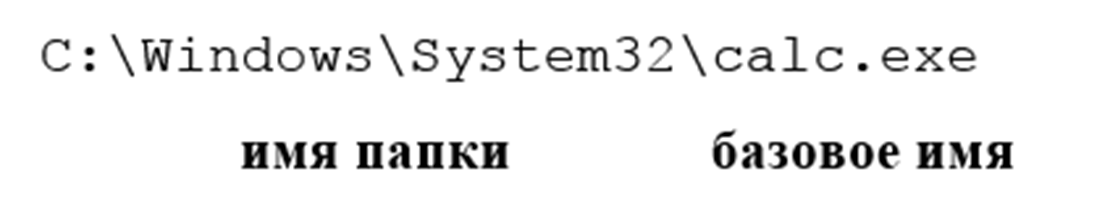

Вызов `os.path.dirname(path)` возвращает строку, содержащую всю часть пути, которая предшествует последней косой черте в аргументе `path`. 
Вызов `os.path.basename(path)` возвращает строку, содержащую всю ту часть пути, которая следует за последней косой чертой в аргументе `path`.


In [19]:
import os
mypath = 'C:\\xampp\\mysql\\bin\\mysql.exe'
print(os.path.basename(mypath))
print(os.path.dirname(mypath))

mysql.exe
C:\xampp\mysql\bin


Для получения как имени папки, так и базового имени, достаточно вызвать функцию `os.path.split()`, которая возвращает кортеж, включающий обе эти строки.


In [2]:
os.path.split(mypath)

('C:\\xampp\\mysql\\bin', 'mysql.exe')

Возвращаемое значение функции os.path.split() не представляет собой список строк, соответствующих каждой из папок пути по отдельности. 

Для получения такого списка следует использовать строковый метод `split()` совместно с разделителем `os.sep`. 

Переменная `os.sep` содержит ту версию косой черты (прямой или обратной), используемой в качестве разделителя имен папок, которая соответствует установленной на компьютере операционной системе.

In [3]:
mypath.split(os.path.sep)

['C:', 'xampp', 'mysql', 'bin', 'mysql.exe']

Строковый метод `split()` обеспечивает возврат списка всех частей пути. 

На компьютерах, работающих под управлением OS X и Linux, в начале возвращенного списка будет указана пустая строка.
Например, для пути `'/usr/bin'` получим `['', 'usr', 'bin']`

#### Доступ к папкам

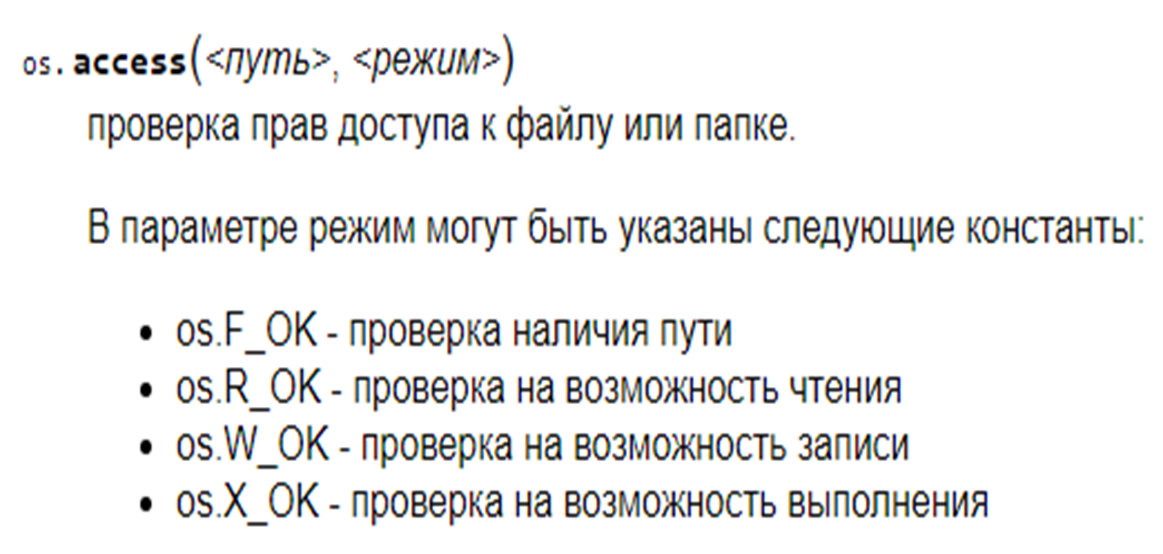

In [4]:
os.access('C:\\Windows\\Temp',os.W_OK)

True

In [5]:
os.access('C:\\ABC',os.X_OK)

True

#### Создание папок

Функция `os.makedirs()` будет создавать все необходимые промежуточные папки, гарантируя существование полного пути.

In [21]:
import os
os.makedirs('C:\\New\\01')

Функция `os.mkdir()` создает папку по указанному пути

In [20]:
os.mkdir('C:\\My\\first')

FileNotFoundError: [WinError 3] Системе не удается найти указанный путь: 'C:\\My\\first'

#### Содержимое папок

Вызов `os.listdir(path)` возвращает список строк с именами всех файлов с путем доступа, указанным в аргументе `path`. (Обратите внимание на то, что эта функция содержится в модуле os, а не в модуле os.path)

In [3]:
os.listdir('C:\\My')

['01',
 '02',
 '56.png',
 'Figure_2.png',
 'first',
 'my',
 'my1',
 'second',
 'text0.txt']

##### Определение размеров файлов 

Модуль `os.path` предоставляет функции, позволяющие находить размеры файлов, выраженные в байтах, и определять файлы и папки, содержащиеся в заданной папке.


Вызов функции `os.path.getsize(path)` возвращает выраженный в байтах размер файла, указанного в аргументе path.

In [10]:
os.path.getsize('C:\\Windows\\System32\\calc.exe')

49152

Найдем суммарный размер всех файлов, находящихся в заданной папке с помощью функций `os.path.getsize()` и `os.listdir()`.

In [11]:
import os

total_size = 0
path = 'C:\\My\\second'
for filename in os.listdir(path):
    total_size += os.path.getsize(os.path.join(path, filename))
print(total_size)

124839


#### Проверка существования пути

Вызов `os.path.isfile(path)` возвращает значение True, если заданный аргументом **путь существует и является файлом**, и значение False в противном случае.

Вызов `os.path.isdir(path)` возвращает значение True, если заданный аргументом **путь существует и является папкой**; иначе — False.


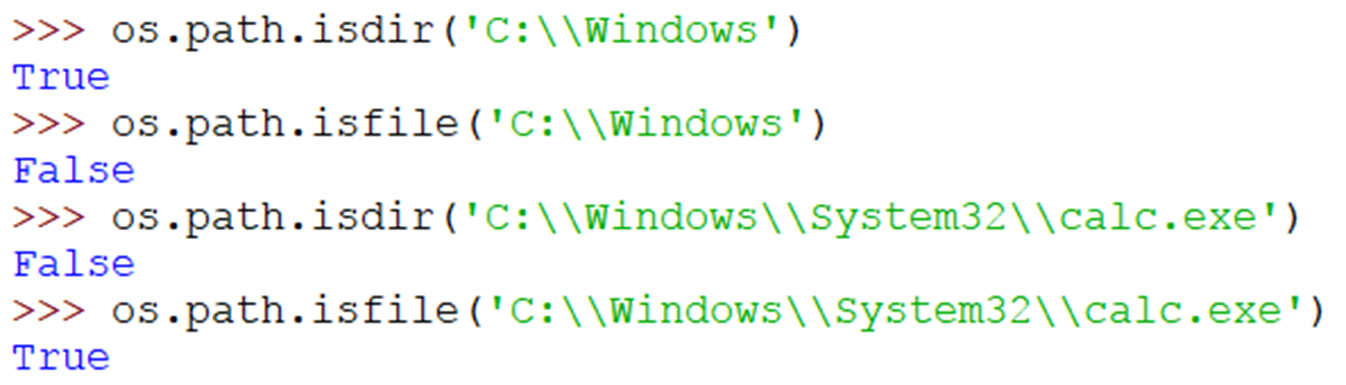

### Управление файлами

#### Модуль shutil

Модуль `shutil` (от англ. "shell utilities" – утилиты командной оболочки) содержит функции, позволяющие копировать, перемещать, переименовывать и удалять файлы с помощью программ на Python. 

In [ ]:
import shutil

Модуль shutil предоставляет функции для копирования файлов и папок.

##### Копирование файлов и папок

Вызов `shutil.сору(исходный путь, путь_назначения)` приведет к копированию файла, расположение которого определяется путем `исходный_путь`, в папку, определяемую путем `путь_назначения`. (Параметры исходный_путь и путь_ назначения являются строками). 


In [ ]:
import shutil
import os

shutil.copy('C:\\My\\text0.txt','C:\\My\\second')

'C:\\My\\second\\t.txt'

Если аргумент `путь_назначения` – это имя файла, то оно будет использовано в качестве нового имени скопированного файла. 
Эта функция возвращает строку, содержащую путь к скопированному файлу.

##### Перемещение и переименование файлов и папок

Вызов функции `shutil.move(исходный_путь, путь_назначения)` перемещает файл или папку из расположения `исходный_путь` в расположение `путь_назначения` и возвращает строку, представляющую абсолютный путь к новому расположению.

Если параметр `путь_назначения` представляет папку, исходный файл перемещается в папку назначения и сохраняет свое текущее имя. 


In [6]:
shutil.move('C:\\My\\second','C:\\')

'C:\\second'

In [16]:
shutil.move('C:\\My\\second\\Figure_2.png','C:\\My')

Error: Destination path 'C:\My\Figure_2.png' already exists

Поскольку таким образом можно очень легко случайно потерять нужный файл, необходимо проявлять определенную осторожность, когда используете функцию `move()`.


In [ ]:
shutil.move('C:\\My\\second\\Figure_1.png','C:\\My\\Figure_1.png')

В следующем примере исходный файл перемещается и переименовывается


In [ ]:
shutil.move('C:\\My\\second\\Figure_1.png','C:\\My\\Figure_2.png')

Предыдущие примеры работают в предположении, что в каталоге `C:\` существует папка, в которую  осуществляется перемещение.

Но если это не так, то функция `move()` переименует перемещаемый файл в файл с именем директории в которую планировали осуществить перемещение.


In [ ]:
shutil.move('C:\\My\\second\\t.txt','C:\\My\\56')

FileNotFoundError: [WinError 3] Системе не удается найти указанный путь

Здесь функция `move()`, не найдя папку `56` в каталоге `C:\My`, предполагает, что путь назначения должен обозначать имя файла, а не папки. 

Поэтому файл `Figure_1.png`  переименовывается в файл `56` (но без расширения)


Задаваемые в качестве исходного пути файлы и папки должны существовать, иначе Python сгенерирует исключение. 

In [18]:
print(os.getcwd())
shutil.move('lab.doc', 'C:\\My')

c:\YandexDisk-it-math.ru\Subjects\ВУМИП\!_Lections\Работа с путями


FileNotFoundError: [WinError 2] Не удается найти указанный файл

Функция `shutil.copytree()` копирует папку вместе со всеми папками и файлами, которые в ней содержатся. 

В результате вызова `shutil.copytree(исходный_путь, путь_назначения)` папка, находящаяся в расположении `исходный_путь`, копируется вместе со всеми находящимися в ней файлами и подпапками в расположение `путь_назначения`. 	

Параметры исходный_путь и путь_назначения являются строками. 
Функция возвращает строку, представляющую путь к копии папки.

In [13]:
shutil.copytree('C:\\My','C:\\My\\my1')

'C:\\My\\my1'

##### Безвозвратное удаление файлов и папок

Функция `os.rmdir(path)`, параметр path – путь к каталогу, удаляет папку по указанному пути

In [14]:
os.rmdir('C:\\My\\del')

OSError: [WinError 145] Папка не пуста: 'C:\\My\\del'

Функция `os.remove(path)`, параметр path – путь к файлу, удаляет файл по указанному пути.
Вызывает исключение `WindowsError` если файл удалить нельзя.

In [16]:
os.remove('C:\\My\\del\\text0.txt')

In [22]:
os.rmdir('C:\\My\\del')

`os.removedirs(path)`, параметр `path` – путь к файлу, аналогичен функции `rmdir`, но автоматически удаляет все родительские пустые папки


Если для удаления одиночного файла или одиночной пустой папки можно воспользоваться функциями, содержащимися в модуле `оs`, то для удаления папки вместе со всем ее содержимым следует использовать модуль `shutil`.

In [17]:
shutil.rmtree('C:\\My0')

In [ ]:
import os
for filename in os.listdir('C:\\My01'):
    if filename.endswith('.txt'):
        #os.remove(os.path.join('C:\\My01',filename)) #os.unlink()
        print(os.path.join('C:\\My01',filename))
        input()



C:\My01\text0 — копия (2).txt
C:\My01\text0 — копия (3).txt
C:\My01\text0 — копия (4).txt
C:\My01\text0 — копия (5).txt
C:\My01\text0 — копия (6).txt
C:\My01\text0 — копия (7).txt
C:\My01\text0 — копия.txt
C:\My01\text0.txt


##### Модуль send2trash

Встроенная функция Python `shutil.rmtree()` необратимо удаляет файлы и папки, ее использование связано с определенным риском. 

Намного лучший способ удаления файлов и папок предлагает модуль `send2trash` от независимых разработчиков.


Этот модуль можно установить, выполнив команду 
`pip install send2trash` 
в окне терминала.

Модуль `send2trash` отправляет удаляемые файлы и папки в корзину компьютера, а не удаляет их безвозвратно. 


In [18]:
import send2trash

send2trash.send2trash('C:\\My\\text0.txt')

### Обход дерева каталогов

Предположим, мы хотим переименовать все файлы, находящиеся в некоторой папке, а также во всех ее подпапках. 

Следовательно, нам необходимо выполнить обход всего дерева каталогов, обрабатывая при этом каждый файл. 

Написание соответствующей программы — задача нетривиальная, и потому Python предоставляет функцию, организующую этот процесс.


Для обхода дерева каталогов используется функция `os.walk()`.

Функции `os.walk()` передается единственное строковое значение – `путь к папке`. 
Можно использовать функцию `os.walk()` в цикле for для обхода дерева каталогов во многом примерно так, как функцию `range()` можно использовать для перебора всех целых чисел, принадлежащих некоторому диапазону. 


Однако, в отличие от функции range(), функция `os.walk()` возвращает три значения на каждой итерации цикла:
1. строку, содержащую текущее имя папки;
2. список строк, представляющих имена папок, которые содержатся в текущей папке;
3. список строк, представляющих имена файлов, которые содержатся в те-кущей папке.

Под текущей папкой подразумевается папка, используемая в текущей итерации цикла. 

Применение функции `os.walk()` не приводит к смене текущего рабочего каталога программы.


Будем использовать соответственно имена `folder`, `subfolders` и `filenames`.


In [19]:
import os

for folder, subfolders, filenames in os.walk('C:\\My'):
    print('Текущая папка' + folder)

    for subfolder in subfolders:
        print(f'Подпапка папки {folder}: {subfolder}')

    for filename in filenames:
        print(f'Файл в папке {folder}: {filename}')
    

Текущая папкаC:\My
Подпапка папки C:\My: 01
Подпапка папки C:\My: 02
Подпапка папки C:\My: del
Подпапка папки C:\My: first
Подпапка папки C:\My: my
Подпапка папки C:\My: second
Файл в папке C:\My: 56 (2).png
Файл в папке C:\My: 56.png
Файл в папке C:\My: Figure_2.png
Текущая папкаC:\My\01
Подпапка папки C:\My\01: 01-1
Подпапка папки C:\My\01: 01-2
Файл в папке C:\My\01: text01.txt
Текущая папкаC:\My\01\01-1
Подпапка папки C:\My\01\01-1: 01-1-1
Файл в папке C:\My\01\01-1: text01-1.txt
Текущая папкаC:\My\01\01-1\01-1-1
Текущая папкаC:\My\01\01-2
Файл в папке C:\My\01\01-2: text02.txt
Текущая папкаC:\My\02
Файл в папке C:\My\02: text02.txt
Текущая папкаC:\My\del
Подпапка папки C:\My\del: 01
Подпапка папки C:\My\del: 02
Подпапка папки C:\My\del: first
Подпапка папки C:\My\del: my
Подпапка папки C:\My\del: second
Файл в папке C:\My\del: 56 (2).png
Файл в папке C:\My\del: 56.png
Файл в папке C:\My\del: Figure_2.png
Текущая папкаC:\My\del\01
Подпапка папки C:\My\del\01: 01-1
Подпапка папки C: